# Generation 2: Good Performance Results

This notebook analyzes the Generation 2 experiments that showed good counterfactual generation performance, specifically:
- **Baseline experiments**: Models trained with standard settings
- **Optimized XGBoost experiments**: Models with hyperparameter tuning

These experiments demonstrated higher validity and solved rates compared to SMOTE and weighted models.

------

In [1]:
# import
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)


In [3]:
import os
from pathlib import Path
from dotenv import load_dotenv
load_dotenv()

ROOT_DIR = Path(os.getenv("PROJECT_ROOT"))

RESULTS_CSV_PATH = ROOT_DIR / "analysis" / "summary_data" / "gen_2_summary.csv"

print("root exists: ", ROOT_DIR.exists())
print("results is file: ", RESULTS_CSV_PATH.is_file())

root exists:  True
results is file:  True


In [4]:
# Add project root to path for imports
import sys
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

In [5]:
df = pd.read_csv(RESULTS_CSV_PATH)

In [6]:
df

,experiment,explainer_type,ml_model_type,use_permitted_range,total_cfs_requested,maxiterations,stopping_threshold,n_patients,total_cfs,valid_cfs,validity_%,solved_%,actionable_%,avg_nchanged_valid,avg_nchanged_all,avg_gower_all,min_gower_all,max_gower_all,low_gower_count_all,low_gower_<0.02_%_all,high_gower_count_all,high_gower_>0.35_%_all,gower_q25_all,gower_median_all,gower_q75_all,avg_gower_valid,min_gower_valid,max_gower_valid,low_gower_count_valid,low_gower_<0.02_%_valid,high_gower_count_valid,high_gower_>0.35_%_valid,avg_risk_before,avg_risk_after,min_risk_after,risk_reduction_%,total_gen_time_sec,avg_gen_time_sec,top_features,csv_path
0,RandomForest_thres0.5_2026-05-11,genetic,RandomForest,True,10,1000,0.5,9,89,28,31.5%,100.0%,89.9%,2.50,2.35,0.19,0.0002,0.4607,4,4.5%,11,12.4%,0.1183,0.1653,0.2505,0.19,0.0569,0.4607,0,0.0%,2,7.1%,0.2571,0.1194,0.0000,70.1,86.48,9.61,bmi: 100% | alcfreq: 36% | slprl: 29% | ...,predictors_vs_threshold/SMOTE/base_predictors/...
1,RandomForest_thres0.9_2026-05-11,genetic,RandomForest,True,10,1000,0.9,9,56,23,41.1%,88.9%,89.3%,2.57,2.25,0.18,0.0001,0.4607,2,3.6%,3,5.4%,0.1217,0.1741,0.2503,0.21,0.0597,0.4607,0,0.0%,2,8.7%,0.2042,0.1016,0.0000,71.9,144.35,16.04,bmi: 100% | alcfreq: 39% | dosprt: 39% | ...,predictors_vs_threshold/SMOTE/base_predictors/...
2,XGBoost_thres0.5_2026-05-11,genetic,XGBoost,True,10,1000,0.5,9,90,30,33.3%,55.6%,88.9%,2.83,2.41,0.20,0.0003,0.5678,5,5.6%,12,13.3%,0.1251,0.1728,0.2528,0.25,0.0177,0.5321,1,3.3%,7,23.3%,0.3452,0.1490,0.0010,74.5,9.40,1.04,bmi: 100% | dosprt: 43% | alcfreq: 40% | ...,predictors_vs_threshold/SMOTE/base_predictors/...
3,XGBoost_thres0.9_2026-05-11,genetic,XGBoost,True,10,1000,0.9,9,50,21,42.0%,66.7%,94.0%,2.86,2.42,0.19,0.0497,0.3796,0,0.0%,5,10.0%,0.1250,0.1581,0.2503,0.21,0.1000,0.3796,0,0.0%,2,9.5%,0.2807,0.1044,0.0021,77.9,9.55,1.06,bmi: 100% | alcfreq: 52% | dosprt: 48% | ...,predictors_vs_threshold/SMOTE/base_predictors/...
4,RandomForest_thres0.5_2026-05-11,genetic,RandomForest,True,10,1000,0.5,9,89,8,9.0%,33.3%,88.8%,3.38,2.39,0.18,0.0002,0.4607,5,5.6%,9,10.1%,0.1122,0.1584,0.2507,0.21,0.1201,0.3147,0,0.0%,0,0.0%,0.3461,0.1402,0.0826,65.7,140.61,15.62,bmi: 100% | alcfreq: 50% | slprl: 50% | ...,predictors_vs_threshold/SMOTE/gridsearched_pre...
5,XGBoost_thres0.5_2026-05-11,genetic,XGBoost,True,10,1000,0.5,9,87,17,19.5%,55.6%,88.5%,3.24,2.37,0.17,0.0001,0.4607,4,4.6%,9,10.3%,0.1103,0.1475,0.2374,0.21,0.0492,0.3892,0,0.0%,2,11.8%,0.3933,0.1828,0.0933,63.3,100.08,11.12,bmi: 100% | alcfreq: 59% | dosprt: 53% | ...,predictors_vs_threshold/SMOTE/gridsearched_pre...
6,RandomForest_thres0.1_2026-05-11,genetic,RandomForest,True,10,1000,0.1,9,63,41,65.1%,100.0%,88.9%,2.37,2.25,0.17,0.0000,0.4712,4,6.3%,4,6.3%,0.0876,0.1259,0.2504,0.18,0.0005,0.4712,1,2.4%,4,9.8%,0.0941,0.0264,0.0000,74.8,24.31,2.70,bmi: 100% | alcfreq: 32% | slprl: 27% | ...,predictors_vs_threshold/baseline/RandomForest_...
7,RandomForest_thres0.5_2026-05-11,genetic,RandomForest,True,10,1000,0.5,9,90,38,42.2%,100.0%,88.9%,2.32,2.20,0.18,0.0004,0.4607,7,7.8%,10,11.1%,0.1135,0.1534,0.2504,0.21,0.0013,0.4607,1,2.6%,7,18.4%,0.1100,0.0333,0.0000,74.1,23.60,2.62,bmi: 100% | slprl: 39% | alcfreq: 32% | ...,predictors_vs_threshold/baseline/RandomForest_...
8,RandomForest_thres0.9_2026-05-11,genetic,RandomForest,True,10,1000,0.9,9,83,39,47.0%,100.0%,88.0%,2.38,2.31,0.18,0.0006,0.4607,4,4.8%,5,6.0%,0.1250,0.1546,0.2414,0.19,0.0008,0.4607,1,2.6%,3,7.7%,0.1012,0.0280,0.0000,76.9,23.38,2.60,bmi: 100% | slprl: 36% | alcfreq: 33% | ...,predictors_vs_threshold/baseline/RandomForest_...
9,XGBoost_thres0.1_2026-05-11,genetic,XGBoost,True,10,1000,0.1,9,70,39,55.7%,77.8%,92.9%,2.15,2.06,0.17,0.0004,0.4607,5,7.1%,2,2.9%,0.1134,0.1473,0.2329,0.17,0.0148,0.3202,2,5.1%,0,0.0%,0.0881,0.0225,0.0003,79.1,10.56,1.17,bmi: 100% | etfruit: 33% | slprl: 21% | ...,predictors_vs_threshold/baseline/XGBoost_thres...


## Filter for Baseline and Optimized Experiments

We'll filter the data to exclude SMOTE and weighted experiments, keeping only the good-performing ones.

In [7]:
# Filter to exclude SMOTE and weighted experiments
df_good = df[~df['csv_path'].str.contains('SMOTE|weighted', regex=True)].copy()
print(f"Total experiments: {len(df)}")
print(f"Baseline + Optimized experiments: {len(df_good)}")
df_good

Total experiments: 17
Baseline + Optimized experiments: 9


,experiment,explainer_type,ml_model_type,use_permitted_range,total_cfs_requested,maxiterations,stopping_threshold,n_patients,total_cfs,valid_cfs,validity_%,solved_%,actionable_%,avg_nchanged_valid,avg_nchanged_all,avg_gower_all,min_gower_all,max_gower_all,low_gower_count_all,low_gower_<0.02_%_all,high_gower_count_all,high_gower_>0.35_%_all,gower_q25_all,gower_median_all,gower_q75_all,avg_gower_valid,min_gower_valid,max_gower_valid,low_gower_count_valid,low_gower_<0.02_%_valid,high_gower_count_valid,high_gower_>0.35_%_valid,avg_risk_before,avg_risk_after,min_risk_after,risk_reduction_%,total_gen_time_sec,avg_gen_time_sec,top_features,csv_path
6,RandomForest_thres0.1_2026-05-11,genetic,RandomForest,True,10,1000,0.1,9,63,41,65.1%,100.0%,88.9%,2.37,2.25,0.17,0.0000,0.4712,4,6.3%,4,6.3%,0.0876,0.1259,0.2504,0.18,0.0005,0.4712,1,2.4%,4,9.8%,0.0941,0.0264,0.0000,74.8,24.31,2.70,bmi: 100% | alcfreq: 32% | slprl: 27% | ...,predictors_vs_threshold/baseline/RandomForest_...
7,RandomForest_thres0.5_2026-05-11,genetic,RandomForest,True,10,1000,0.5,9,90,38,42.2%,100.0%,88.9%,2.32,2.20,0.18,0.0004,0.4607,7,7.8%,10,11.1%,0.1135,0.1534,0.2504,0.21,0.0013,0.4607,1,2.6%,7,18.4%,0.1100,0.0333,0.0000,74.1,23.60,2.62,bmi: 100% | slprl: 39% | alcfreq: 32% | ...,predictors_vs_threshold/baseline/RandomForest_...
8,RandomForest_thres0.9_2026-05-11,genetic,RandomForest,True,10,1000,0.9,9,83,39,47.0%,100.0%,88.0%,2.38,2.31,0.18,0.0006,0.4607,4,4.8%,5,6.0%,0.1250,0.1546,0.2414,0.19,0.0008,0.4607,1,2.6%,3,7.7%,0.1012,0.0280,0.0000,76.9,23.38,2.60,bmi: 100% | slprl: 36% | alcfreq: 33% | ...,predictors_vs_threshold/baseline/RandomForest_...
9,XGBoost_thres0.1_2026-05-11,genetic,XGBoost,True,10,1000,0.1,9,70,39,55.7%,77.8%,92.9%,2.15,2.06,0.17,0.0004,0.4607,5,7.1%,2,2.9%,0.1134,0.1473,0.2329,0.17,0.0148,0.3202,2,5.1%,0,0.0%,0.0881,0.0225,0.0003,79.1,10.56,1.17,bmi: 100% | etfruit: 33% | slprl: 21% | ...,predictors_vs_threshold/baseline/XGBoost_thres...
10,XGBoost_thres0.5_2026-05-11,genetic,XGBoost,True,10,1000,0.5,9,90,39,43.3%,77.8%,88.9%,2.23,2.16,0.17,0.0005,0.4607,9,10.0%,6,6.7%,0.0849,0.1522,0.2448,0.17,0.0019,0.3618,1,2.6%,2,5.1%,0.1023,0.0373,0.0007,71.9,9.90,1.10,bmi: 100% | etfruit: 28% | slprl: 26% | ...,predictors_vs_threshold/baseline/XGBoost_thres...
11,XGBoost_thres0.9_2026-05-11,genetic,XGBoost,True,10,1000,0.9,9,83,42,50.6%,100.0%,90.4%,2.45,2.29,0.19,0.0008,0.4607,5,6.0%,7,8.4%,0.1254,0.1801,0.2546,0.20,0.0407,0.3857,0,0.0%,3,7.1%,0.0966,0.0257,0.0005,77.6,10.46,1.16,bmi: 100% | etfruit: 36% | alcfreq: 36% |...,predictors_vs_threshold/baseline/XGBoost_thres...
14,XGBoost_thres0.1_2026-05-11,genetic,XGBoost,True,10,1000,0.1,9,65,26,40.0%,88.9%,89.2%,2.50,2.22,0.18,0.0004,0.4607,4,6.2%,5,7.7%,0.1250,0.1459,0.2500,0.18,0.0170,0.3761,1,3.8%,3,11.5%,0.0620,0.0137,0.0004,82.7,10.54,1.17,bmi: 100% | etfruit: 42% | alcfreq: 38% |...,predictors_vs_threshold/xgb_optimized/XGBoost_...
15,XGBoost_thres0.5_2026-05-11,genetic,XGBoost,True,10,1000,0.5,9,90,28,31.1%,88.9%,88.9%,2.50,2.27,0.17,0.0000,0.4607,7,7.8%,6,6.7%,0.0909,0.1394,0.2489,0.17,0.0313,0.3440,0,0.0%,0,0.0%,0.0632,0.0133,0.0003,82.8,10.32,1.15,bmi: 100% | dosprt: 43% | etfruit: 36% | ...,predictors_vs_threshold/xgb_optimized/XGBoost_...
16,XGBoost_thres0.9_2026-05-11,genetic,XGBoost,True,10,1000,0.9,9,86,35,40.7%,100.0%,89.5%,2.23,2.14,0.17,0.0000,0.4607,6,7.0%,6,7.0%,0.0938,0.1534,0.2504,0.17,0.0084,0.3796,2,5.7%,2,5.7%,0.0651,0.0112,0.0007,84.4,10.86,1.21,bmi: 100% | etfruit: 31% | eatveg: 29% | ...,predictors_vs_threshold/xgb_optimized/XGBoost_...


In [8]:
# Create a category column for better grouping
df_good['category'] = df_good['csv_path'].apply(
    lambda x: 'Baseline' if 'baseline' in x
              else 'Optimized XGBoost'
)

# Add model abbreviation
df_good['model_abbr'] = df_good['ml_model_type'].str[:3]

df_good[['experiment', 'category', 'ml_model_type', 'stopping_threshold', 'validity_%', 'solved_%']]

,experiment,category,ml_model_type,stopping_threshold,validity_%,solved_%
6,RandomForest_thres0.1_2026-05-11,Baseline,RandomForest,0.1,65.1%,100.0%
7,RandomForest_thres0.5_2026-05-11,Baseline,RandomForest,0.5,42.2%,100.0%
8,RandomForest_thres0.9_2026-05-11,Baseline,RandomForest,0.9,47.0%,100.0%
9,XGBoost_thres0.1_2026-05-11,Baseline,XGBoost,0.1,55.7%,77.8%
10,XGBoost_thres0.5_2026-05-11,Baseline,XGBoost,0.5,43.3%,77.8%
11,XGBoost_thres0.9_2026-05-11,Baseline,XGBoost,0.9,50.6%,100.0%
14,XGBoost_thres0.1_2026-05-11,Optimized XGBoost,XGBoost,0.1,40.0%,88.9%
15,XGBoost_thres0.5_2026-05-11,Optimized XGBoost,XGBoost,0.5,31.1%,88.9%
16,XGBoost_thres0.9_2026-05-11,Optimized XGBoost,XGBoost,0.9,40.7%,100.0%


In [9]:
# Prepare data for visualization
df_good["Validity_%"] = df_good["validity_%"].str.rstrip('%').astype(float)
df_good["Solved_%"] = df_good["solved_%"].str.rstrip('%').astype(float)
df_good["Actionable_%"] = df_good["actionable_%"].str.rstrip('%').astype(float)
df_good["Time"] = df_good["total_gen_time_sec"]

# Create labels
df_good["Category"] = df_good["category"]
df_good["Model"] = df_good["ml_model_type"]
df_good["Threshold"] = df_good["stopping_threshold"]

# Number of changes metrics
df_good["Avg_NChanged_All"] = df_good["avg_nchanged_all"]
df_good["Avg_NChanged_Valid"] = df_good["avg_nchanged_valid"]

# Gower distance metrics - ALL CFs
# Note: Column names now include threshold values (e.g., "low_gower_<0.02_%_all")
df_good["Avg_Gower_All"] = df_good["avg_gower_all"]
low_col_all = [c for c in df_good.columns if c.startswith("low_gower_<") and c.endswith("_%_all")][0]
high_col_all = [c for c in df_good.columns if c.startswith("high_gower_>") and c.endswith("_%_all")][0]
df_good["Low_Gower_%_All"] = df_good[low_col_all].str.rstrip('%').astype(float)
df_good["High_Gower_%_All"] = df_good[high_col_all].str.rstrip('%').astype(float)
df_good["Median_Gower_All"] = df_good["gower_median_all"]

# Gower distance metrics - VALID CFs only
df_good["Avg_Gower_Valid"] = df_good["avg_gower_valid"]
low_col_valid = [c for c in df_good.columns if c.startswith("low_gower_<") and c.endswith("_%_valid")][0]
high_col_valid = [c for c in df_good.columns if c.startswith("high_gower_>") and c.endswith("_%_valid")][0]
df_good["Low_Gower_%_Valid"] = df_good[low_col_valid].str.rstrip('%').astype(float)
df_good["High_Gower_%_Valid"] = df_good[high_col_valid].str.rstrip('%').astype(float)
df_good["Min_Gower_Valid"] = df_good["min_gower_valid"]

# Add risk metrics for additional analysis
df_good["Risk_Before"] = df_good["avg_risk_before"] * 100  # Convert to percentage
df_good["Risk_After"] = df_good["avg_risk_after"] * 100    # Convert to percentage
df_good["Risk_Reduction_%"] = df_good["risk_reduction_%"]

# Display summary
df_good[["Category", "Model", "Threshold", "Validity_%", "Solved_%", "Time", "Avg_Gower_All", "Avg_Gower_Valid"]].sort_values(['Category', 'Model', 'Threshold'])

,Category,Model,Threshold,Validity_%,Solved_%,Time,Avg_Gower_All,Avg_Gower_Valid
6,Baseline,RandomForest,0.1,65.1,100.0,24.31,0.17,0.18
7,Baseline,RandomForest,0.5,42.2,100.0,23.60,0.18,0.21
8,Baseline,RandomForest,0.9,47.0,100.0,23.38,0.18,0.19
9,Baseline,XGBoost,0.1,55.7,77.8,10.56,0.17,0.17
10,Baseline,XGBoost,0.5,43.3,77.8,9.90,0.17,0.17
11,Baseline,XGBoost,0.9,50.6,100.0,10.46,0.19,0.20
14,Optimized XGBoost,XGBoost,0.1,40.0,88.9,10.54,0.18,0.18
15,Optimized XGBoost,XGBoost,0.5,31.1,88.9,10.32,0.17,0.17
16,Optimized XGBoost,XGBoost,0.9,40.7,100.0,10.86,0.17,0.17


## Combined Visualization: All Metrics in One View

Combining performance and risk metrics for comprehensive analysis, similar to the bad performance notebook.

In [10]:
# Reshape data for performance metrics (Row 1)
df_melted_combined = df_good.melt(
    id_vars=["Category", "Model", "Threshold"],
    value_vars=["Validity_%", "Solved_%", "Time", "Avg_NChanged_All"],
    var_name="Metric",
    value_name="Value"
)

# Reshape data for risk metrics (Row 2)
df_risk_melted = df_good.melt(
    id_vars=["Category", "Model", "Threshold"],
    value_vars=["Risk_Before", "Risk_After", "Risk_Reduction_%", "Avg_NChanged_Valid"],
    var_name="Metric",
    value_name="Value"
)

# Reshape data for Gower ALL metrics (Row 3)
df_gower_all = df_good.melt(
    id_vars=["Category", "Model", "Threshold"],
    value_vars=["Avg_Gower_All", "Low_Gower_%_All", "High_Gower_%_All", "Median_Gower_All"],
    var_name="Metric",
    value_name="Value"
)

# Reshape data for Gower VALID metrics (Row 4)
df_gower_valid = df_good.melt(
    id_vars=["Category", "Model", "Threshold"],
    value_vars=["Avg_Gower_Valid", "Low_Gower_%_Valid", "High_Gower_%_Valid", "Min_Gower_Valid"],
    var_name="Metric",
    value_name="Value"
)

print("Performance metrics shape:", df_melted_combined.shape)
print("Risk metrics shape:", df_risk_melted.shape)
print("Gower ALL metrics shape:", df_gower_all.shape)
print("Gower VALID metrics shape:", df_gower_valid.shape)

Performance metrics shape: (36, 5)
Risk metrics shape: (36, 5)
Gower ALL metrics shape: (36, 5)
Gower VALID metrics shape: (36, 5)


### English Version 

(<Figure size 1600x1400 with 16 Axes>,
 array([[<Axes: title={'center': 'Validity (%)'}, xlabel='Threshold', ylabel='Validity (%)'>,
         <Axes: title={'center': 'Solved Observations (%)'}, xlabel='Threshold', ylabel='Solved Observations (%)'>,
         <Axes: title={'center': 'Time (s)'}, xlabel='Threshold', ylabel='Time (s)'>,
         <Axes: >],
        [<Axes: title={'center': 'Risk Before (%)'}, xlabel='Threshold', ylabel='Risk Before (%)'>,
         <Axes: title={'center': 'Risk Reduction (%)'}, xlabel='Threshold', ylabel='Risk Reduction (%)'>,
         <Axes: title={'center': 'Avg # Changes (All)'}, xlabel='Threshold', ylabel='Avg # Changes (All)'>,
         <Axes: title={'center': 'Avg # Changes (Valid)'}, xlabel='Threshold', ylabel='Avg # Changes (Valid)'>],
        [<Axes: title={'center': 'Avg Gower (All)'}, xlabel='Threshold', ylabel='Avg Gower (All)'>,
         <Axes: title={'center': 'Low Gower <0.02 % (All)'}, xlabel='Threshold', ylabel='Low Gower <0.02 % (All)'>,
  

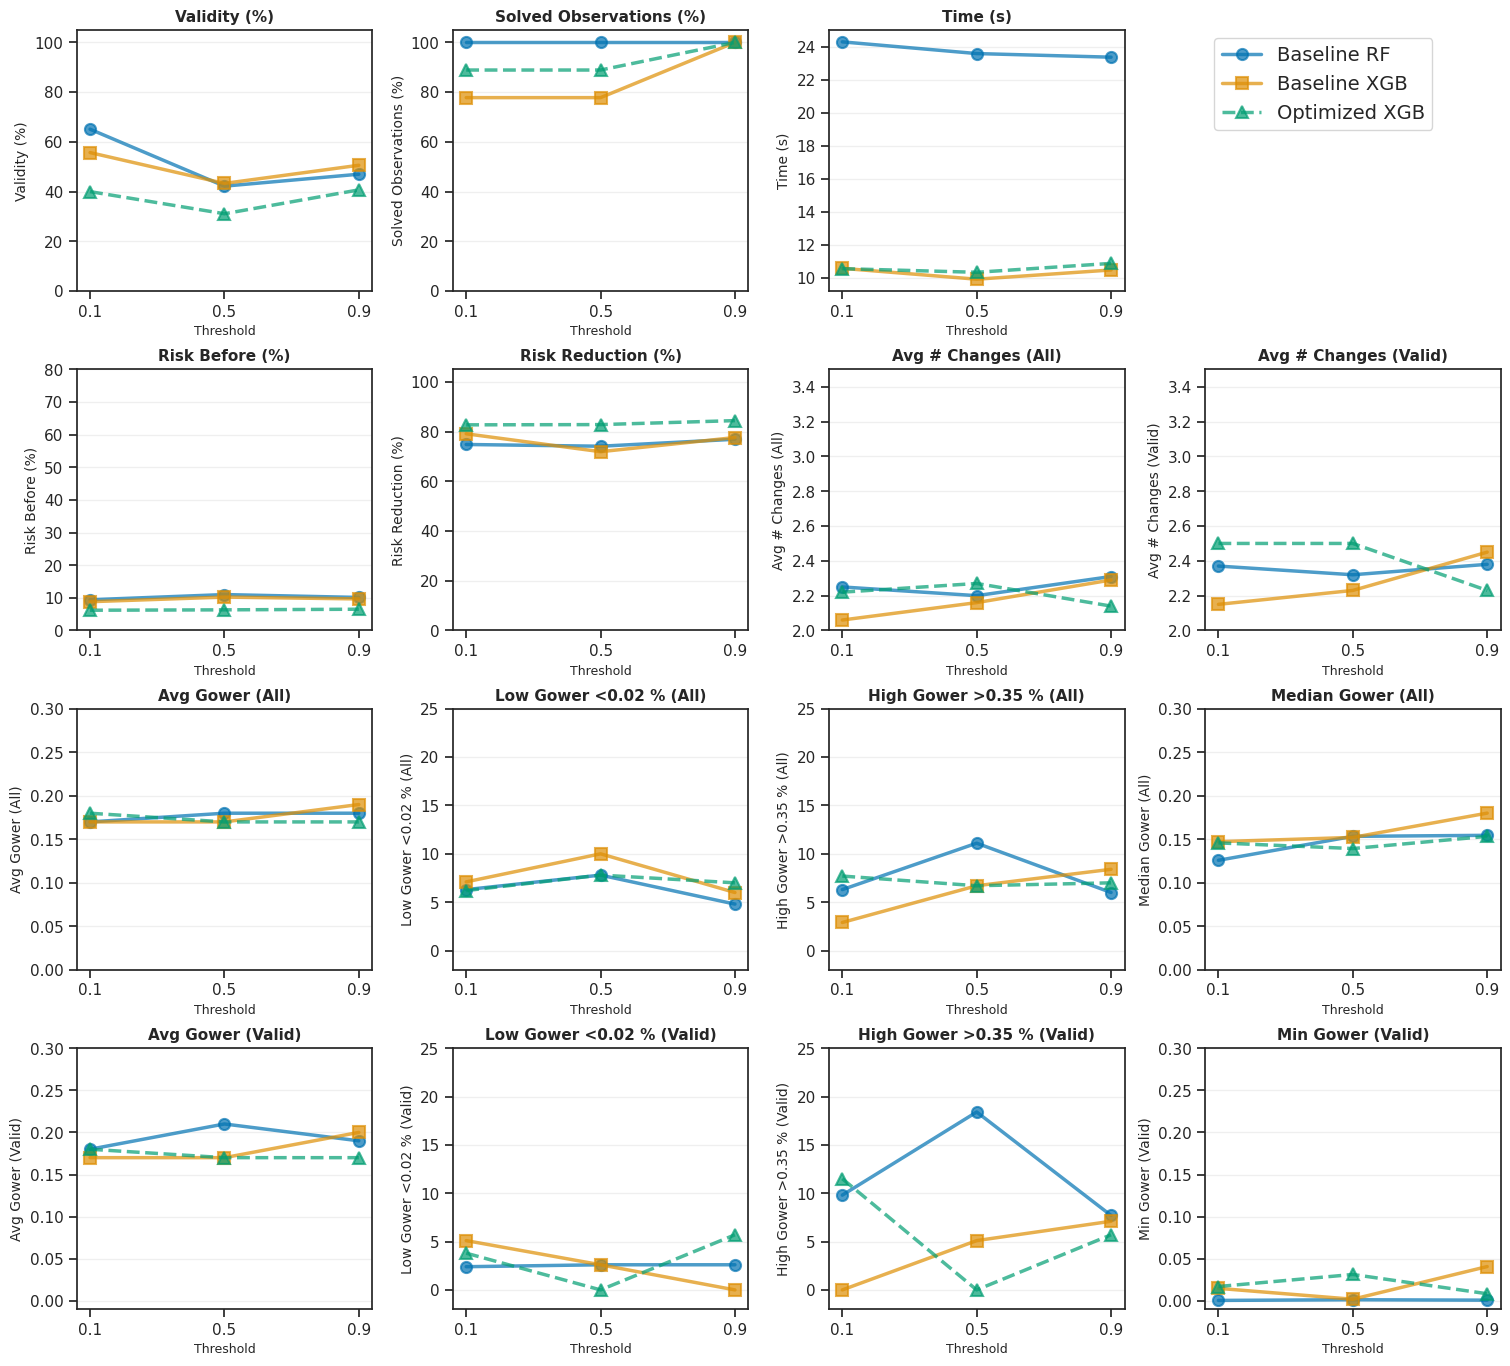

In [11]:
# Swedish version - Using updated viz module
from analysis.viz import create_comprehensive_plot_good

# Create plot - threshold on X-axis, 3 model configurations as lines
create_comprehensive_plot_good(df_good, language='en', figsize=(16, 14))